# Preview - see other notebook for details.

In [1]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from IPython.display import display, Markdown
import rasterio
from rasterio.transform import Affine

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "scripts/discussion_checkpoint.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
# Refresh plotting helpers when rerunning this cell in an existing IDE kernel.
import importlib
import scripts.discussion_checkpoint as checkpoint_helpers
importlib.reload(checkpoint_helpers)
from scripts.discussion_checkpoint import (
    load_scenes, projected_box, reference_figure, observed_montage, comparison_panel,
    radiance_figure, residual_figure, cluster_scene, cluster_figures, close_comparison,
    file_hash, COLORS, image_normalizations,
)

# Main discussion controls. Geographic bounds only select the same area across grids.
ZOOM_WGS84 = (-89.48, 35.94, -89.18, 36.17)  # Dyersburg + Newbern, eastern Dyer
CLOSE_WGS84 = (-89.425, 36.005, -89.345, 36.080)  # Dyersburg close-up
ZOOM = projected_box(*ZOOM_WGS84)
CLOSE = projected_box(*CLOSE_WGS84)
IMAGE_DATES = pd.date_range("2025-04-02", "2025-04-14")
SERIES_DATES = pd.date_range("2025-04-02", "2025-04-14")
CLUSTER_DATES = pd.date_range("2025-04-07", "2025-04-14")
CLOSE_DATES = pd.to_datetime(["2025-04-08", "2025-04-09", "2025-04-11"])
N_CLUSTERS = 4
MIN_CLUSTER_DATES = 4
CLUSTER_MAX_ITER = 120
CLUSTER_SEED = 7
# None = full displayed-data range, shared across datasets and nights.
RADIANCE_VMAX = None
RESIDUAL_LIMIT = None
RESIDUAL_LINTHRESH = 0.5  # Linear band is +/- this radiance value.

OUTPUT = ROOT / "data/published/discussion_checkpoint_preview"
OUTPUT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"font.size": 10, "figure.dpi": 110, "savefig.dpi": 140})
print("Verifying and loading existing inputs; the 10 m arrays stay memory-mapped...")
scenes, input_hashes = load_scenes(ROOT)
for scene in scenes.values():
    print(scene.title, scene.observed.shape)


# Normalize colors only: arrays, model outputs, statistics, and clusters stay in original units.
RADIANCE_NORM, RESIDUAL_NORM = image_normalizations(
    scenes, ZOOM, IMAGE_DATES, close=CLOSE, close_dates=CLOSE_DATES,
    radiance_vmax=RADIANCE_VMAX, residual_limit=RESIDUAL_LIMIT,
    linthresh=RESIDUAL_LINTHRESH,
)
RADIANCE_VMAX = float(RADIANCE_NORM.vmax)
RESIDUAL_LIMIT = float(RESIDUAL_NORM.vmax)
print(f"Shared log1p radiance colors: 0 to {RADIANCE_VMAX:.3g}")
print(f"Shared symmetric-log residual colors: +/-{RESIDUAL_LIMIT:.3g}; linear within +/-{RESIDUAL_LINTHRESH}")


Verifying and loading existing inputs; the 10 m arrays stay memory-mapped...
VIIRS A2 · matched native support (72, 81, 139)
Reallocation · native ~500 m (72, 81, 139)
Reallocation · 10 m proxy (72, 4097, 5533)
Shared log1p radiance colors: 0 to 396
Shared symmetric-log residual colors: +/-206; linear within +/-0.5


In [2]:
# Export helpers. Run the notebook in order; the final cell closes the PDF.
report_pdf = PdfPages(OUTPUT / "discussion_checkpoint_preview.pdf")
figure_paths = []
cluster_summaries = []
cluster_results = {}


def publish(fig, name):
    path = OUTPUT / f"{name}.png"
    fig.savefig(path, dpi=140, facecolor="white")
    report_pdf.savefig(fig, facecolor="white")
    figure_paths.append(path)
    display(fig)
    plt.close(fig)


def save_table(table, name):
    table.to_csv(OUTPUT / f"{name}.csv", index=False)


def save_cluster_map(scene, image, name, info):
    rr, cc, _, _ = scene.region(ZOOM)
    transform = scene.transform @ Affine.translation(cc.start, rr.start)
    path = OUTPUT / f"{name}.tif"
    with rasterio.open(path, "w", driver="COG", width=image.shape[1], height=image.shape[0],
                       count=1, dtype="uint8", crs=f"EPSG:{scene.crs}", transform=transform,
                       nodata=0, compress="DEFLATE", overview_resampling="NEAREST") as dst:
        dst.write(np.where(np.isfinite(image), image, 0).astype("uint8"), 1)
        dst.update_tags(description="Exploratory residual clusters; not outage labels",
                        palette=json.dumps({str(i+1): c for i, c in enumerate(COLORS[:info["clusters"]])}))


## Baseline reference method is median radiance for each cell during baseline period (Feb 5 to Apr 1, 2025)
This looks similar for the BlackMarble product VNP46A2 as does the reallocation (Crull method) when aggregated up to 500m. The reallocation method at 10m shows the built environment structure in detail, but the median radiance and residuals are relatively similar.

Here's a view of the baseline radiance (median for the feb-apr baseline period) for VNP46A2

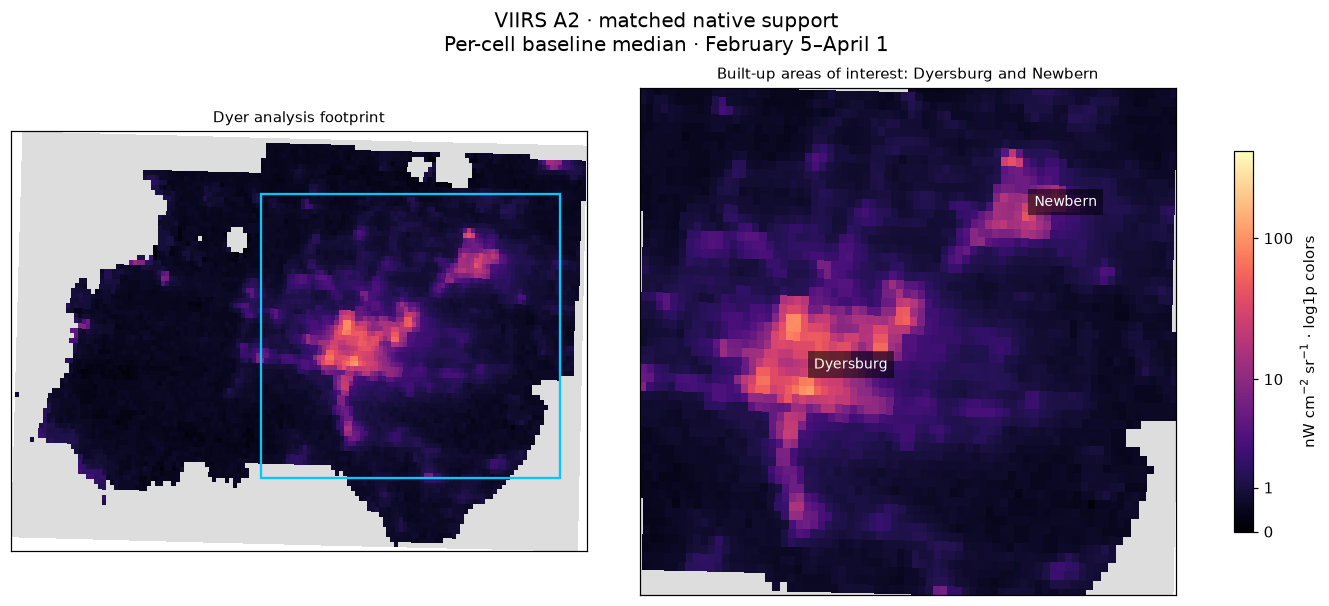

In [3]:
scene = scenes["a2"]
method = "M0"
prefix = "1a"
publish(reference_figure(scene, ZOOM, RADIANCE_VMAX, norm=RADIANCE_NORM), f"{prefix}_reference")

### Baseline / observed / residual comparison

One row per date. The left image is the same baseline median in every row; the
center is observed radiance and the right is observed minus the **M0 prediction**.
M0 uses the baseline median as its reference for supported cells.

The challenge of missing data on the nightly cadence (likely due to cloud masking) is obvious.

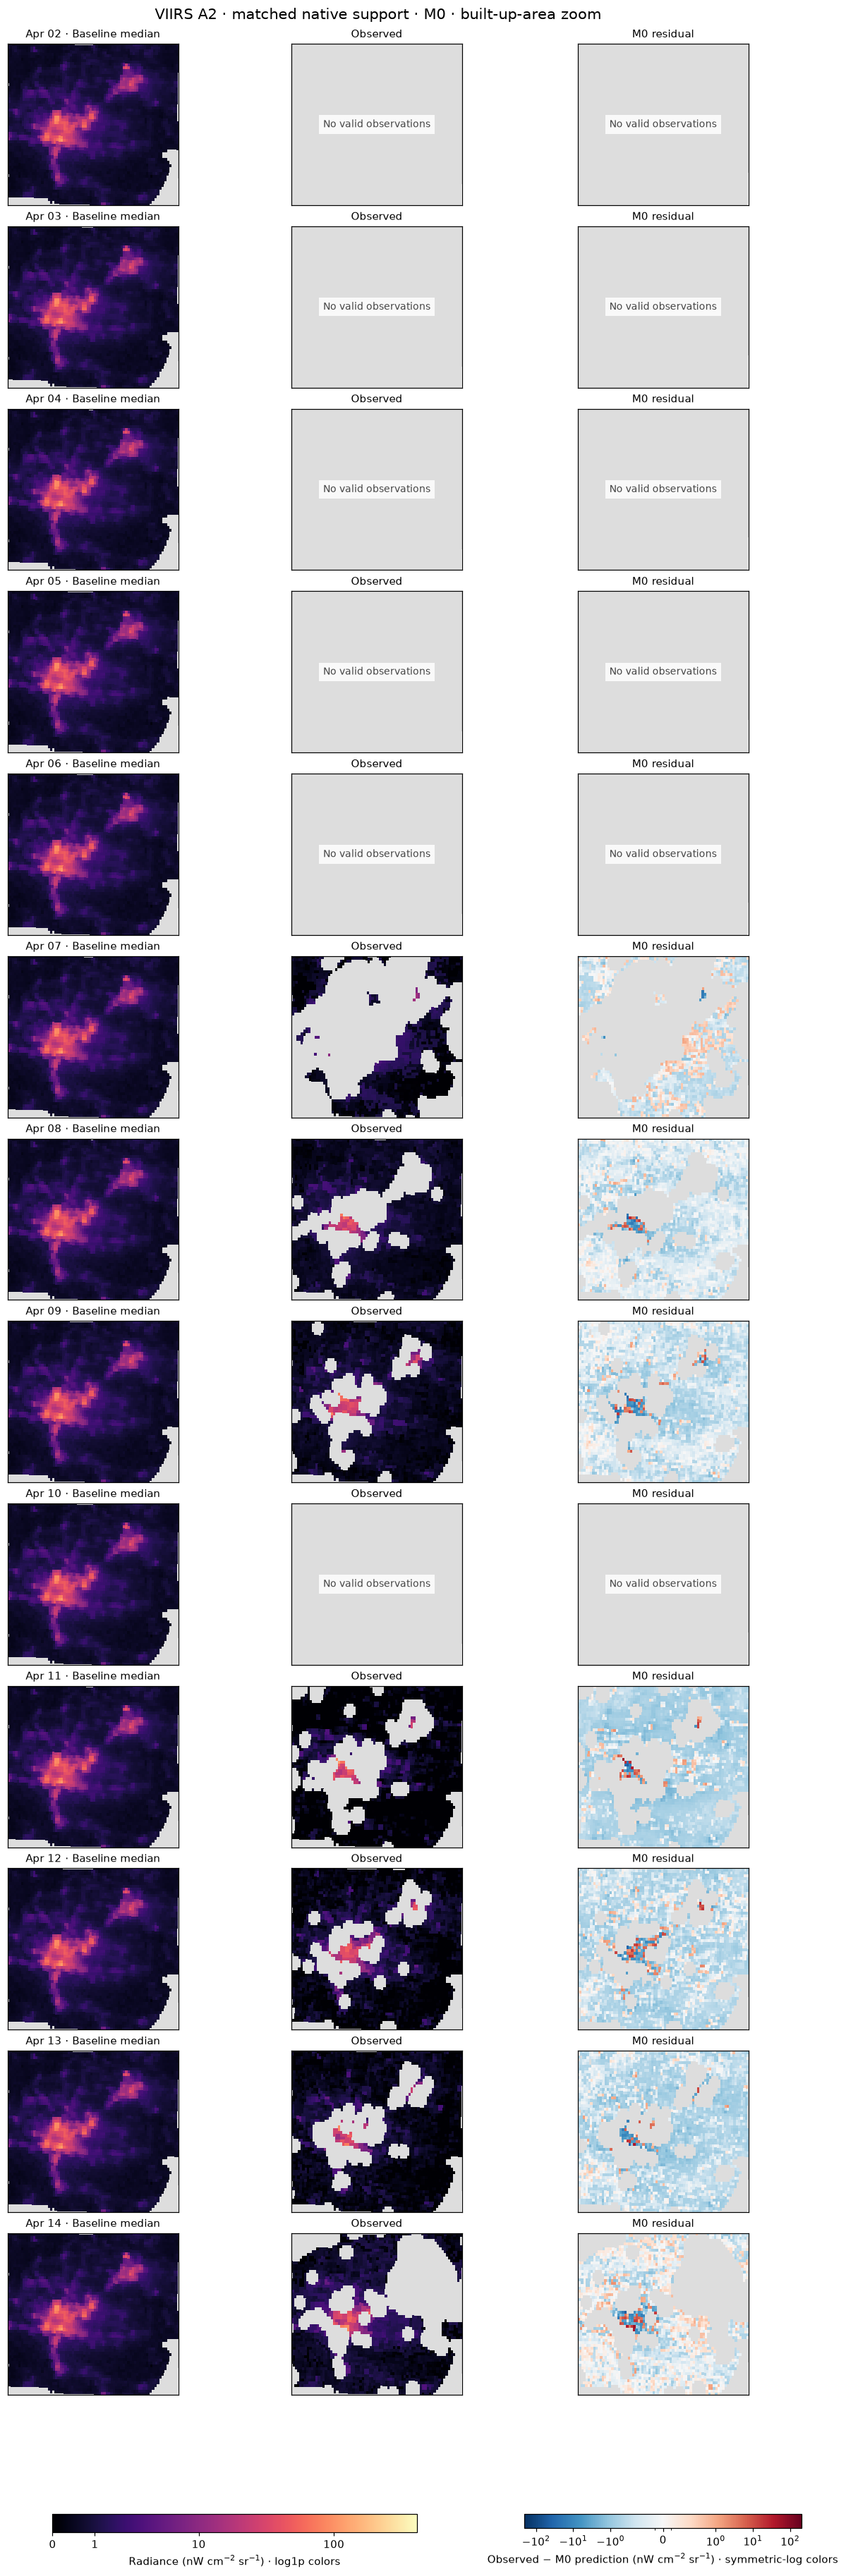

In [4]:
publish(comparison_panel(scene, method, ZOOM, IMAGE_DATES, RADIANCE_VMAX, RESIDUAL_LIMIT,
                         radiance_norm=RADIANCE_NORM, residual_norm=RESIDUAL_NORM),
        f"{prefix}_comparison")

### As can be seen, the baseline and residual patterns are similar for the reallocated (500m) output.

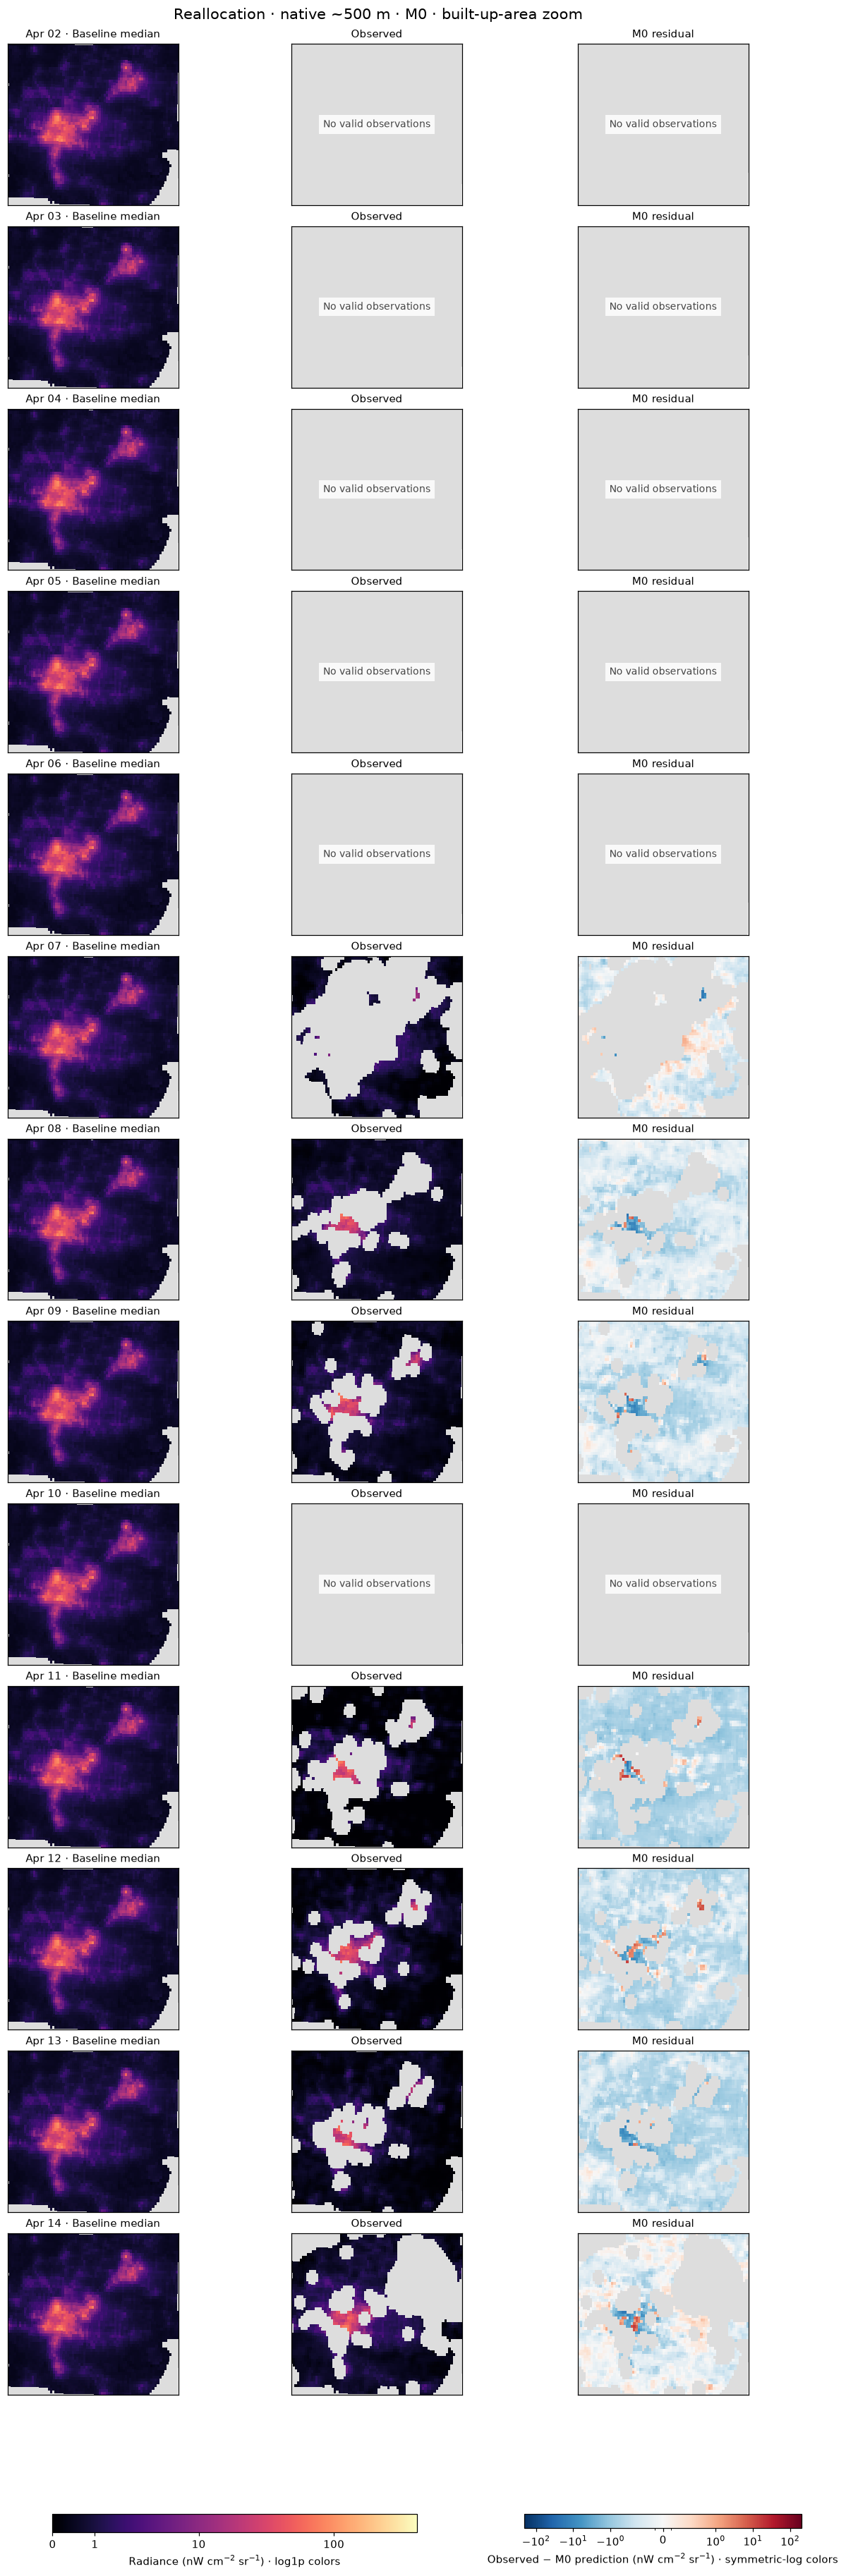

In [5]:
scene = scenes["allocated500"]
method = "M0"
prefix = "1b"
publish(comparison_panel(scene, method, ZOOM, IMAGE_DATES, RADIANCE_VMAX, RESIDUAL_LIMIT,
                         radiance_norm=RADIANCE_NORM, residual_norm=RESIDUAL_NORM),
        f"{prefix}_comparison")

### The reallocated layer at 10m shows more structure around the built environment. As we'll look at later, this allows for some interesting insight into exact outage mapping (as well as areas of unexpected brightness: recovery staging sites?)

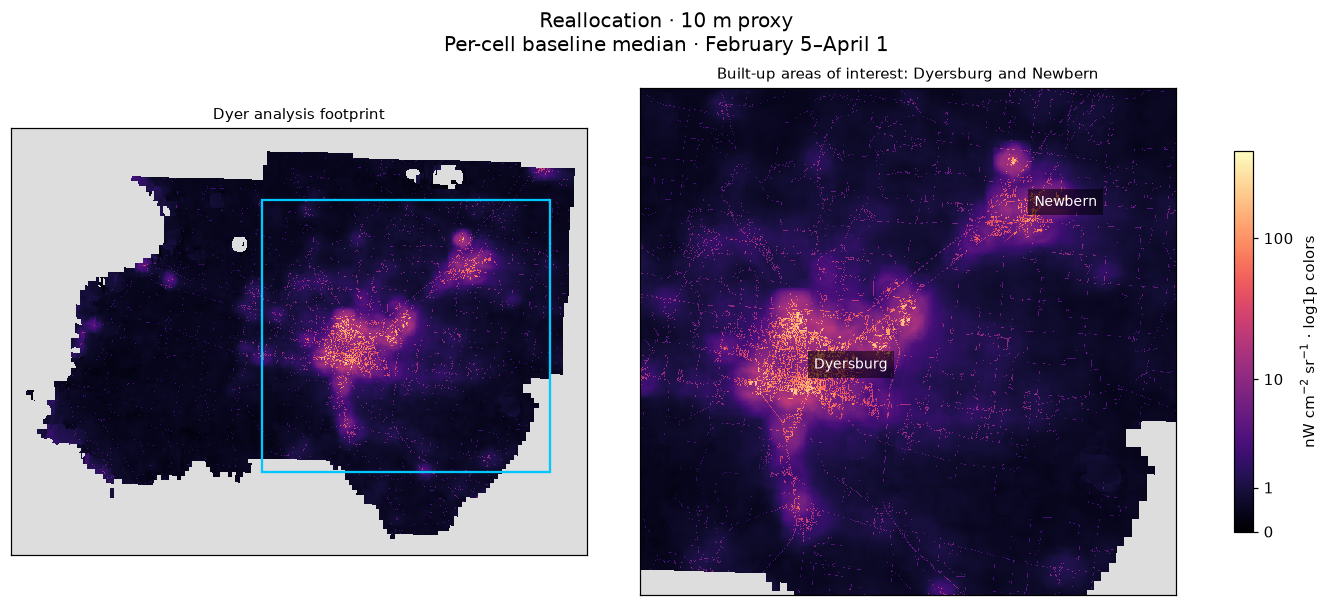

In [6]:
scene = scenes["allocated10"]
method = "M0"
prefix = "1c"
publish(reference_figure(scene, ZOOM, RADIANCE_VMAX, norm=RADIANCE_NORM), f"{prefix}_01_reference")

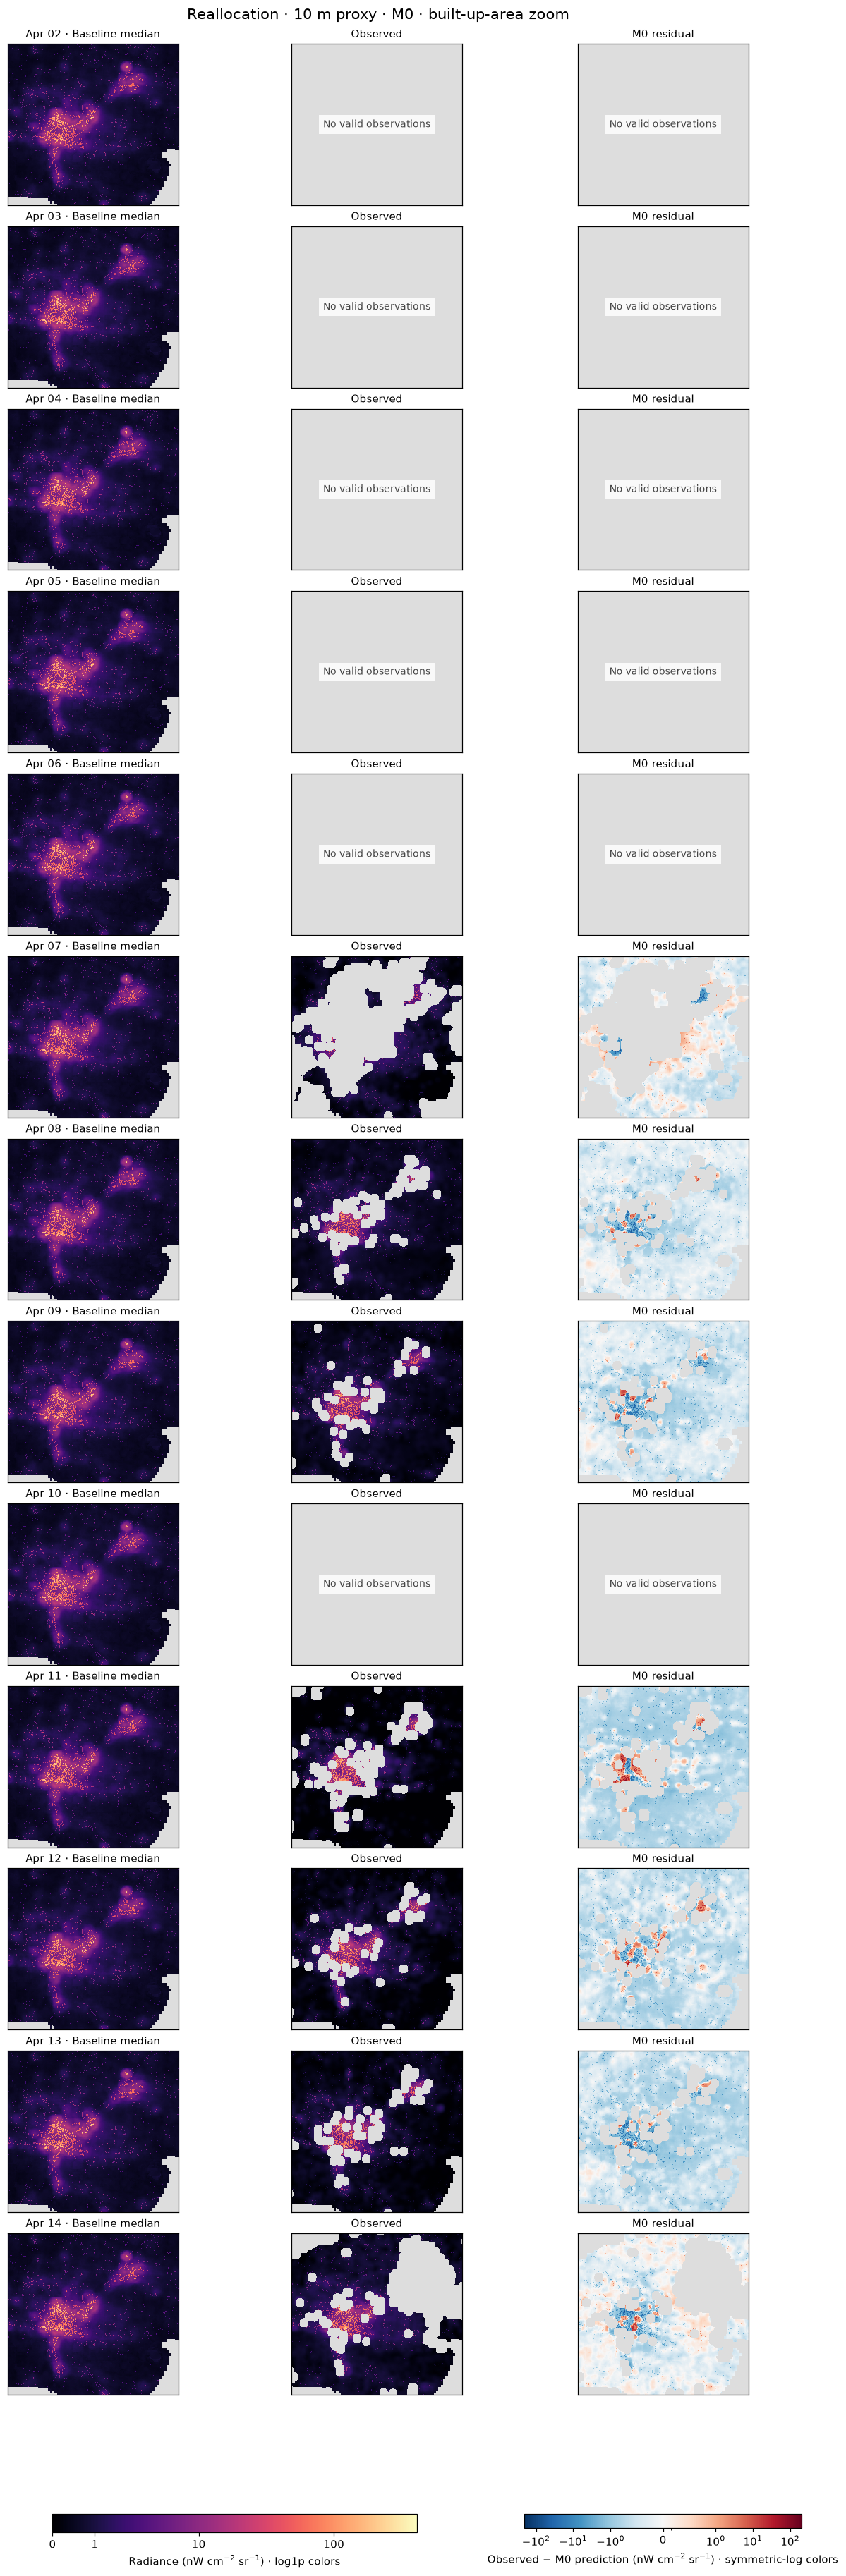

In [7]:
publish(comparison_panel(scene, method, ZOOM, IMAGE_DATES, RADIANCE_VMAX, RESIDUAL_LIMIT,
                         radiance_norm=RADIANCE_NORM, residual_norm=RESIDUAL_NORM),
        f"{prefix}_comparison")

### Spatial-median time series

The first plot summarizes the **full scene**, and the second summarizes only the
built-up-area zoom. Each reference line is the median of baseline nightly spatial
medians for that same area. Missing observations are excluded; an entirely missing
night has no plotted point. The contributing pixel set can vary by night.

The time series for all methods (VIIRS A2, reallocation at 500m and reallocation at 10m) are somewhat similar so here we're just showing the VIIRS A2 time series. There are no valid observations the first few nights, but then we see notably lower radiance and a dip w/ a minimum on April 11, then recovery over the next 3-4 days.

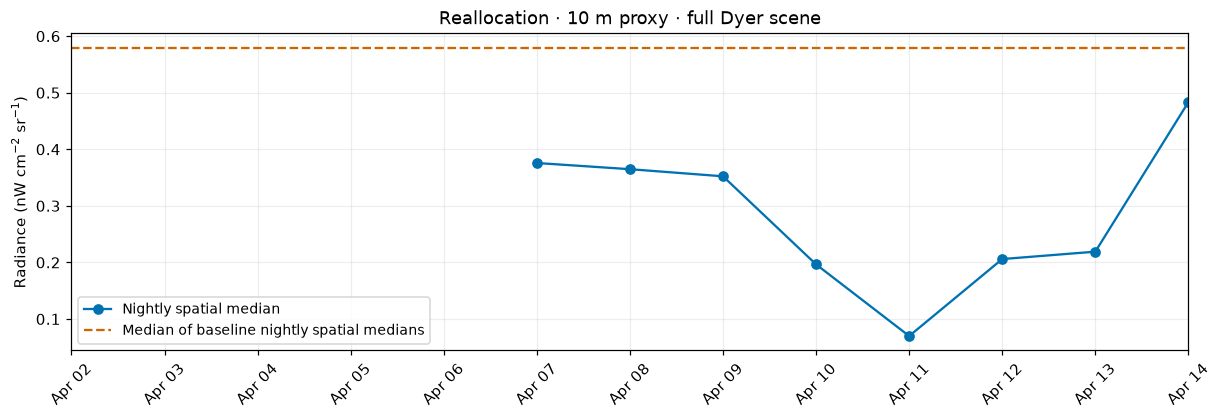

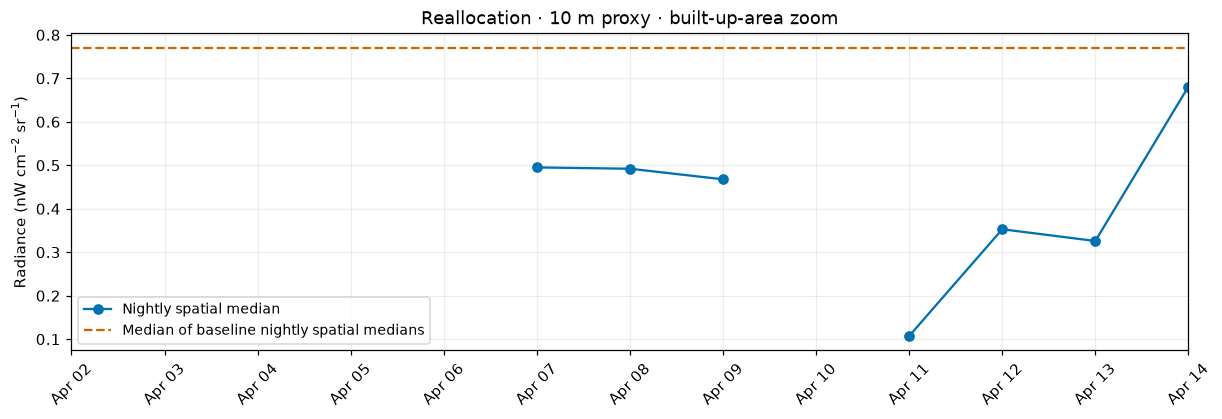

In [8]:
fig, table = radiance_figure(scene, SERIES_DATES)
publish(fig, f"{prefix}_04_full_scene_radiance")
save_table(table, f"{prefix}_full_scene_radiance")
fig, table = radiance_figure(scene, SERIES_DATES, ZOOM, "built-up-area zoom")
publish(fig, f"{prefix}_05_zoom_radiance")
save_table(table, f"{prefix}_zoom_radiance")

### Exploratory residual clusters

Cluster raw residual trajectories from April 7–14. Cells need at least four valid
residual dates; missing entries have zero weight in the distance and centroid
updates. Residual amplitude is retained (no per-cell standardization). The clustering
uses all eligible pixels, without requiring spatial adjacency. Cluster labels are
ordered from lower to higher mean centroid residual, **not by outage confidence**.

Group medians use the available observations within each group on each date, so
membership is fixed but the contributing subset may change. Colors match exactly
between the profile plot and spatial map. Inspect the convergence and coverage
summary below before interpreting groups.

These clusters are similar for the BlackMarble A2 and reallocation at 500m outputs, so just showing the BlackMarble A2 here.

Clustering Reallocation · 10 m proxy / M0 at full input resolution...


,eligible_pixels,clusters,iterations,converged,minimum_observed_dates,seed,section,dataset,method
0,5965562,4,46,True,4,7,1c,allocated10,M0


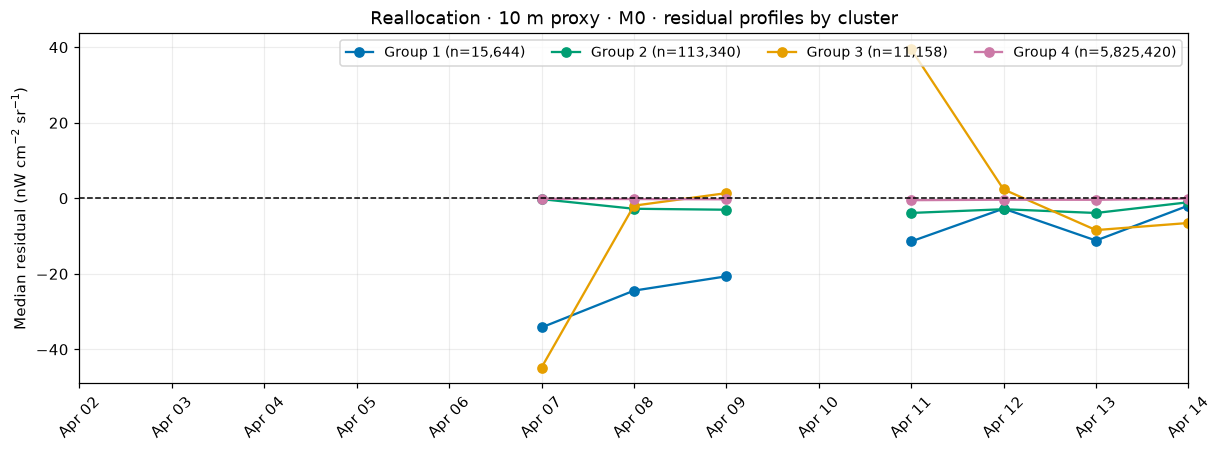

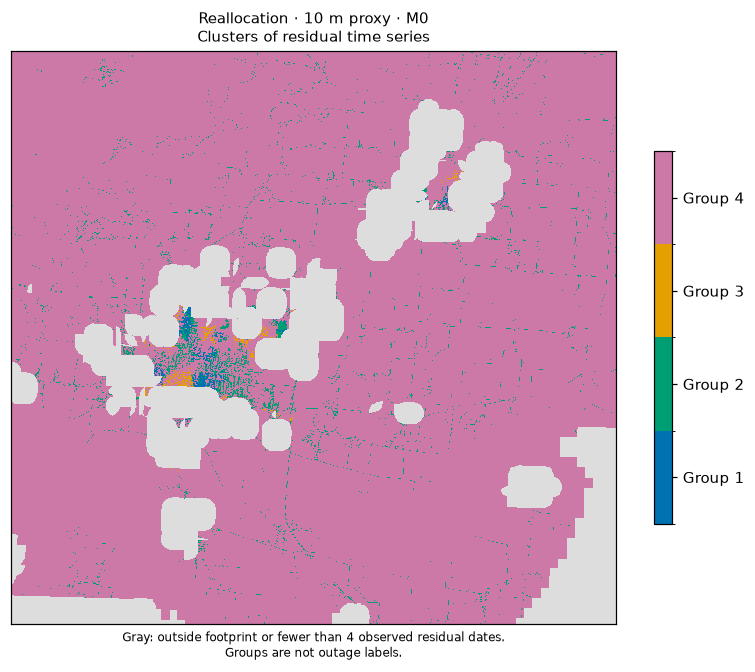

In [9]:
print(f"Clustering {scene.title} / {method} at full input resolution...")
cluster_image, cluster_table, cluster_info = cluster_scene(
    scene, method, ZOOM, CLUSTER_DATES, k=N_CLUSTERS, min_dates=MIN_CLUSTER_DATES,
    max_iter=CLUSTER_MAX_ITER, seed=CLUSTER_SEED,
)
cluster_info.update(section=prefix, dataset=scene.key, method=method)
cluster_summaries.append(cluster_info)
cluster_results[prefix] = cluster_info
save_table(cluster_table, f"{prefix}_cluster_profiles")
save_cluster_map(scene, cluster_image, f"{prefix}_clusters", cluster_info)
display(pd.DataFrame([cluster_info]).drop(columns=["used_date_columns"]))
profile_figure, map_figure = cluster_figures(
    scene, method, ZOOM, SERIES_DATES, cluster_image, cluster_table, cluster_info,
)
publish(profile_figure, f"{prefix}_07_cluster_profiles")
publish(map_figure, f"{prefix}_08_cluster_map")
del cluster_image, cluster_table

**Cluster observations:**
Group 1: Dominated by missing data
Group 2: Possible outage area, w/ lower radiance that recovers toward Apr 14
Group 3: Low light/rural areas that dont show much change (not evidence of outage, just very low radiance so median remains about the same)
Group 4: Adjacent to the outage cluster, but shows a spike of *above* normal radiance for a couple nights. An outlier? Perhaps indication of recovery staging lights? 

## Clustering for reallocation at 10m
Due to the more precise spatial resolution, clustering here shows some more detail but the clusters seem largely coherent with before: a group that represents low light / rural (Group 4), Groups 1 an 2 seem to show outage areas, with Group 1 having the lowest dip. Group 3 shows those cells with above normal radiance.

Clustering Reallocation · 10 m proxy / M0 at full input resolution...


,eligible_pixels,clusters,iterations,converged,minimum_observed_dates,seed,section,dataset,method
0,5965562,4,46,True,4,7,1c,allocated10,M0


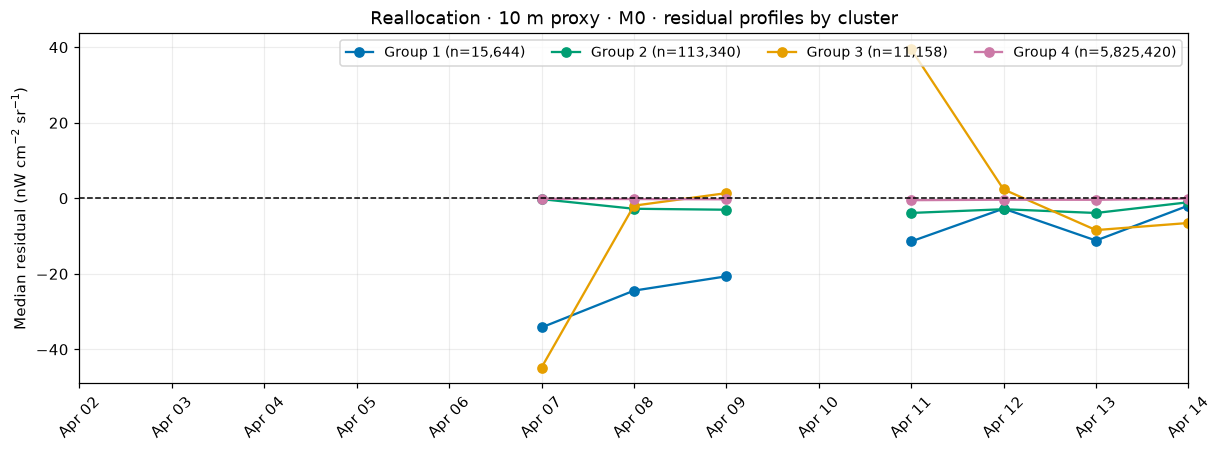

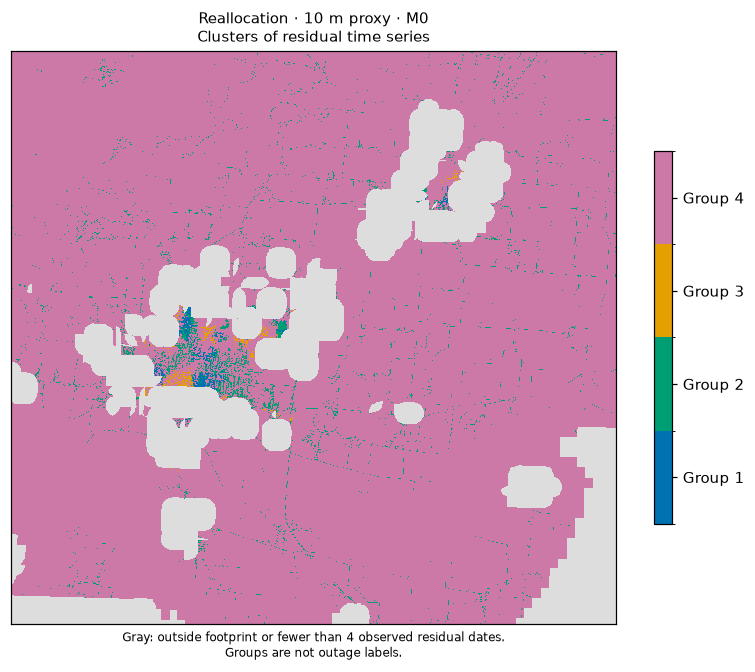

In [10]:
print(f"Clustering {scene.title} / {method} at full input resolution...")
cluster_image, cluster_table, cluster_info = cluster_scene(
    scene, method, ZOOM, CLUSTER_DATES, k=N_CLUSTERS, min_dates=MIN_CLUSTER_DATES,
    max_iter=CLUSTER_MAX_ITER, seed=CLUSTER_SEED,
)
cluster_info.update(section=prefix, dataset=scene.key, method=method)
cluster_summaries.append(cluster_info)
cluster_results[prefix] = cluster_info
save_table(cluster_table, f"{prefix}_cluster_profiles")
save_cluster_map(scene, cluster_image, f"{prefix}_clusters", cluster_info)
display(pd.DataFrame([cluster_info]).drop(columns=["used_date_columns"]))
profile_figure, map_figure = cluster_figures(
    scene, method, ZOOM, SERIES_DATES, cluster_image, cluster_table, cluster_info,
)
publish(profile_figure, f"{prefix}_07_cluster_profiles")
publish(map_figure, f"{prefix}_08_cluster_map")
del cluster_image, cluster_table